### Импорт библиотек

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.optimize as opt

# Часть 3:  Использование логистической регрессии для решения задачи множественной классификации – распознавания рукописных цифр от 0 до 9

В этой части задания нужно было решить задачу классификации рукописных цифр от 0 до 9 с помощью множественной логистической регрессии, а точнее метода one-vs-all.

### Загрузка данных

In [12]:
data3 = pd.read_csv('data/ex2data3.txt', header=None)
data3.head()

,0,1,2,3,4,5,6,7,8,9,...,391,392,393,394,395,396,397,398,399,400
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Преобразование данных

In [13]:
X = np.column_stack([np.ones(len(data3)), data3.iloc[:, :-1]])
y = data3.iloc[:, -1].values
theta = np.zeros(X.shape[1])

### Визуализация данных

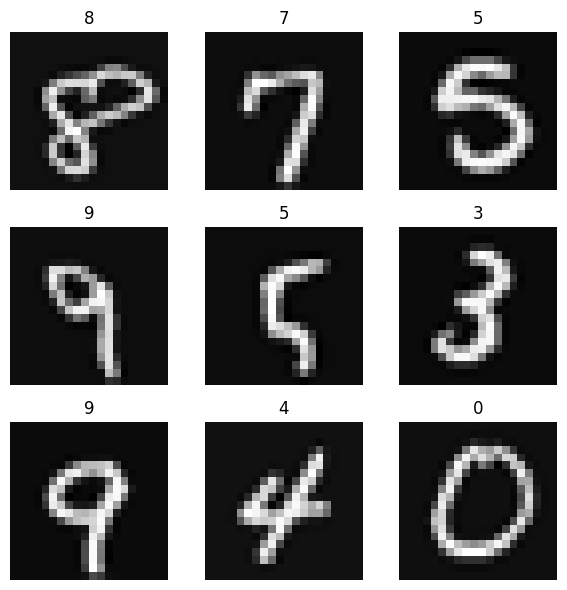

In [14]:
n, m = 3, 3
fig, axes = plt.subplots(n, m, figsize=(6,6))
for i, idx in enumerate(np.random.choice(range(X.shape[0]), n*m)):
    img = X[idx, 1:].reshape(20, 20).T
    axes[i//n, i%m].imshow(img, cmap='gray')
    axes[i//n, i%m].set_title(f"{int(y[idx])}")
    axes[i//n, i%m].axis('off')

plt.tight_layout()
plt.show()

### Определение сигмоиды

In [15]:
def sigmoid(z: float) -> float:
    return 1 / (1 + np.exp(-z))

### Функция стоимости

In [16]:
def costFuncR(theta: np.ndarray, X: np.ndarray, y: np.ndarray, lam: float) -> float:
    h = sigmoid(X.dot(theta))
    regularization = (lam / (2*len(y))) * np.sum(theta[1:]**2)
    J = -(1/len(y)) * np.sum(np.log(h) @ y + np.log(1-h) @ (1-y)) + regularization
    return J

print(f'Cost at initial theta: {costFuncR(theta, X, y, 1)}')

Cost at initial theta: 0.6931471805599413


### Градиент функции стоимости

In [17]:
def gradientFuncR(theta: np.ndarray, X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    y = y.reshape(-1, 1)
    theta = theta.reshape(-1, 1)
    h = sigmoid(X @ theta)
    grad = (1/len(y)) * X.T @ (h-y)
    grad[1:] = grad[1:] + lam/len(y) * theta[1:]
    return grad.flatten()

print(f'Gradient at initial theta: {gradientFuncR(theta, X, y, 1)}')

Gradient at initial theta: [-4.00000000e+00  0.00000000e+00  0.00000000e+00 -7.74530186e-08
  3.19876600e-06  1.89536237e-05 -7.06376094e-04 -8.97395355e-04
 -3.72741263e-04 -1.10036928e-04 -1.50685532e-04 -4.27334678e-05
  3.10558960e-05  7.56273049e-05  1.66101324e-04  1.88959823e-04
  1.11618541e-04  3.44740605e-05  2.31849497e-07 -3.65944989e-07
  0.00000000e+00 -2.71480120e-07  2.68348312e-06  1.35802658e-06
  5.16557921e-05  8.42599350e-05 -1.15506656e-03 -4.06572843e-03
 -5.67501307e-03 -4.45151530e-03 -1.32943478e-03  3.63431691e-04
  4.47602575e-04 -4.04037782e-05 -6.79748502e-04 -6.42352184e-04
 -1.96922564e-04  6.81026859e-05  1.56475973e-04  4.71302424e-05
  1.64277642e-05  2.32894093e-06 -2.61429416e-05  6.07579192e-05
 -2.70628356e-04 -2.15979523e-03 -1.11162067e-02 -2.42933248e-02
 -3.22117731e-02 -2.60633285e-02 -1.45272997e-02 -9.39678887e-03
 -6.17099870e-03 -8.07257483e-03 -1.67791569e-02 -2.10039059e-02
 -1.20593592e-02 -3.62827803e-03 -9.08846282e-04  1.30526191e-0

### One-vs-all классификатор

In [18]:
def predict(theta: np.ndarray, X: np.ndarray) -> np.ndarray:
    return (sigmoid(X @ theta) >= 0.5).astype(int)

def MultiClassifier(X: np.ndarray, y: np.ndarray, lam: float, n: int) -> np.ndarray:
    thetas = np.zeros((n, X.shape[1]))
    initial_theta = np.zeros(X.shape[1])
    predictions, accuracies = list(), list()

    for i in range(n):
        y_bin = (y == i).astype(int)
        model = opt.fmin_tnc(
            func = costFuncR,
            x0 = initial_theta,
            fprime = gradientFuncR,
            args = (X, y_bin, lam))

        thetas[i] = model[0]
        current_predict = predict(thetas[i], X)

        predictions.append(current_predict)
        accuracies.append((current_predict == y_bin).mean()*100)

    overall_acc = sum(accuracies) / len(accuracies)
    print(f'Общая точность на обучающей выборке: {overall_acc:.2f}%')

    # Точность по каждому классу
    print('\nТочность по классам:')
    for i in range(n):
        print(f'Точность по классу {i}: {accuracies[i]:.2f}%')

    return thetas

### Обучение классификаторов

In [19]:
thetas = MultiClassifier(X, y, 1, 10)

  NIT   NF   F                       GTG
    0    1  6.931471805599467E-01   2.88474253E+00
    1    6  7.682550855324134E-02   4.04825995E-03
    2   16  3.250487177064874E-02   3.10474237E-04
tnc: fscale = 56.7528
    3   24  2.333821768289151E-02   4.02339024E-05
    4   27  2.161529933395539E-02   5.98199814E-06
    5   33  2.056848992946854E-02   1.32693267E-06
    6   41  2.018743237591349E-02   8.99485433E-07
    7   48  2.015374522061875E-02   2.98850132E-08
tnc: fscale = 5784.6
    8   56  2.014864708935202E-02   4.88941988E-08
    9   64  2.014777137861402E-02   3.54376553E-10
   10   73  2.014762622995184E-02   5.94363110E-10
   11   81  2.014757640455527E-02   4.50944578E-10
   12   93  2.014754370553274E-02   6.21561325E-12
tnc: fscale = 401105
tnc: |fn-fn-1] = 4.1516e-09 -> convergence
   13  102  2.014753955393547E-02   1.27139362E-12
tnc: Converged (|f_n-f_(n-1)| ~= 0)
  NIT   NF   F                       GTG
    0    1  6.931471805599467E-01   3.58944746E+00
    1    5

Общая точность на обучающей выборке: 98.46%

Точность по классам:
Точность по классу 0: 99.74%
Точность по классу 1: 99.36%
Точность по классу 2: 98.10%
Точность по классу 3: 98.20%
Точность по классу 4: 98.66%
Точность по классу 5: 97.96%
Точность по классу 6: 99.26%
Точность по классу 7: 98.84%
Точность по классу 8: 96.92%
Точность по классу 9: 97.52%


   14  120  8.931063309882242E-02   5.03261995E-10
tnc: fscale = 44576.2
   15  128  8.931060479649328E-02   7.55255739E-10
tnc: |fn-fn-1] = 9.54977e-09 -> convergence
   16  139  8.931059524672151E-02   1.58594717E-10
tnc: Converged (|f_n-f_(n-1)| ~= 0)


### Вычисление вероятностей и оценка

In [20]:
h = sigmoid(np.dot(X, thetas.T))
h_argmax = np.argmax(h, axis=1)
y = y.astype(int)
accuracy = np.mean(h_argmax == y) * 100
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 94.46%
